In [1]:
#We will utilize the yfinance library to retrieve historical volatility data and implement the GARCH 
#(Generalized Autoregressive Conditional Heteroskedasticity) model to estimate and forecast volatility.
#Volatility is a crucial aspect of financial markets as it measures the degree of variation in the price of a financial instrument over time. 
#Accurate volatility forecasting can assist traders and investors in making informed decisions and managing risk effectively.
#ARCH models work best with high-frequency data (hourly, daily, monthly, quarterly), so they are ideal for financial data.

In [2]:
#!pip install yfinance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
%matplotlib inline
import seaborn as sns
from datetime import datetime

from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

In [4]:
volatility_data = pd.read_csv("TCS_sales.csv")

In [5]:
volatility_data.head()

,date,1. open,2. high,3. low,4. close,5. volume
0,2025-03-31,549.83,560.7112,546.87,559.39,95328213.0
1,2025-03-28,565.53,566.2675,555.07,555.66,71662653.0
2,2025-03-27,567.18,570.9000,564.94,567.08,42164248.0
3,2025-03-26,575.19,576.3300,567.19,568.59,52228898.0
4,2025-03-25,575.30,576.4100,573.69,575.46,38355735.0


In [6]:
#The columns represent:
#Open: Opening price of the stock
#High: Highest price during the trading day
#Low: Lowest price during the trading day
#Close: Closing price of the stock
#Volume: Number of shares traded

In [7]:
# Convert column year in datetime format
volatility_data['date'] = pd.to_datetime(volatility_data['date'])
volatility_data = volatility_data.set_index('date')

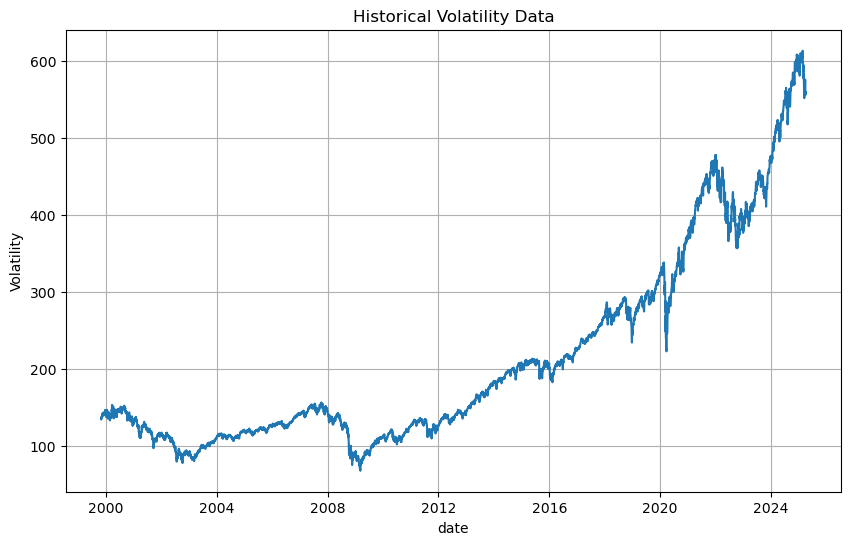

In [8]:
# Plot the historical volatility data
plt.figure(figsize=(10, 6))
plt.plot(volatility_data.index, volatility_data["4. close"])
plt.xlabel("date")
plt.ylabel("Volatility")
plt.title("Historical Volatility Data")
plt.grid(True)

plt.show()

In [9]:
#The line plot provides a visual representation of the volatility data over time. 
#It helps us identify any trends, seasonality, or outliers present in the data.

In [10]:
#!pip install arch

In [11]:
# Calculate log returns
returns = np.log(volatility_data["4. close"]).diff().dropna()

In [12]:
#The log returns represent the percentage change in the volatility data from one period to the next. 
# log returns Stabilizes variance: Unlike raw percentage returns, log returns make time series more stationary.
#They are commonly used in financial analysis as they provide a more meaningful representation of the data.

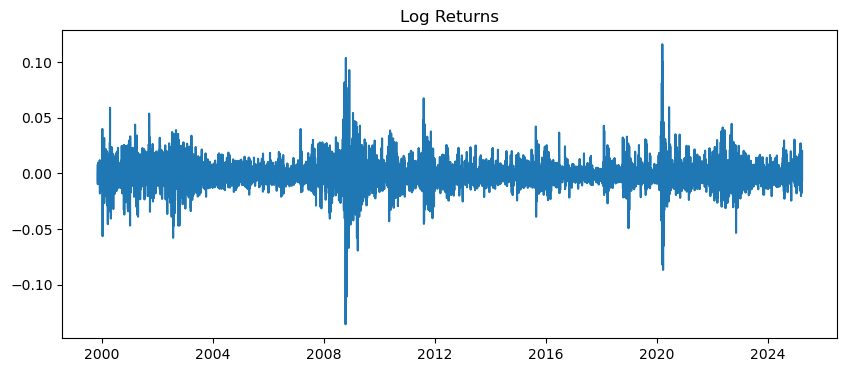

In [13]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("Log Returns")
plt.show()

In [14]:
#Arch effect is seen

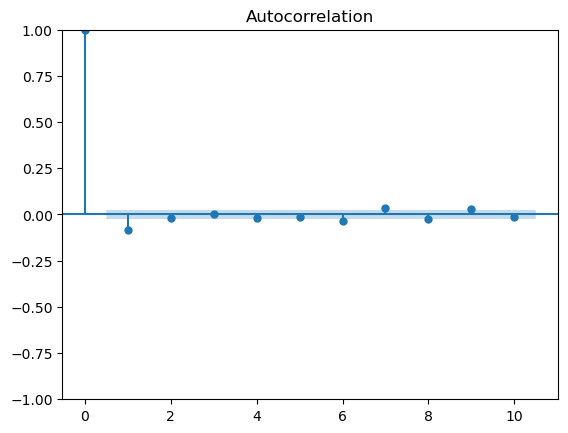

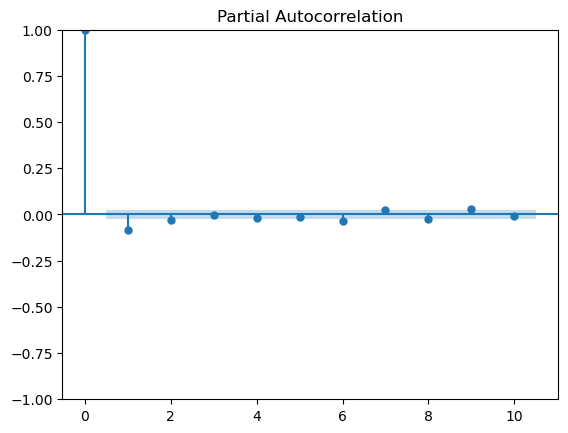

In [15]:
plot_acf(returns, lags = 10)
plt.show()
plot_pacf(returns, lags = 10)
plt.show()

In [16]:
from statsmodels.tsa.arima.model import ARIMA
mean_model = ARIMA(returns, order=(0,0,0)).fit()
residuals = mean_model.resid

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-

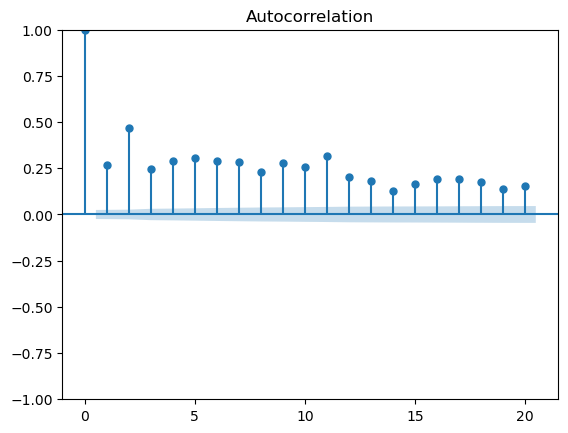

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(residuals**2, lags=20)
plt.show()

In [18]:
#shows Heteroscedasticity.. Thus do ARCH model

In [19]:
#Perform ARCH Test

In [20]:
arch_test = het_arch(returns)
print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 1845.3703870101267
p-value: 0.0


In [21]:
#pvalue<0.05 implies ARCH effect is present

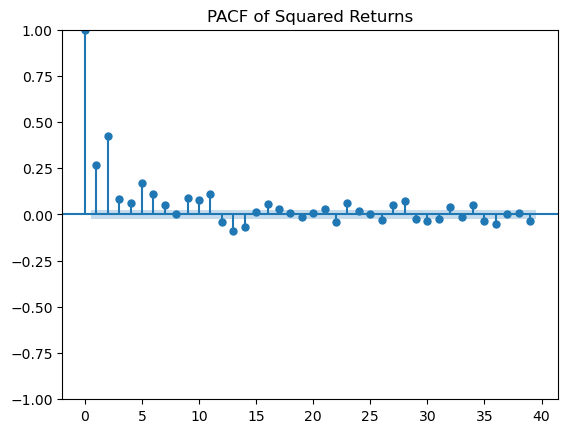

In [22]:
plot_pacf(returns**2)
plt.title("PACF of Squared Returns")
plt.show()

In [23]:
# Fit an ARCH(1) model to the returns data
model_arch = arch_model(returns, vol='ARCH', p=1, rescale = True)  # p=1 for ARCH(1)
model_fit_arch = model_arch.fit()
# can fit Arch (2) also from pacf of returns^2

Iteration:      1,   Func. Count:      5,   Neg. LLF: 56343.55561598078
Iteration:      2,   Func. Count:     13,   Neg. LLF: 4283064.36156024
Iteration:      3,   Func. Count:     19,   Neg. LLF: 10066.03912963106
Iteration:      4,   Func. Count:     25,   Neg. LLF: 13706.635535260086
Iteration:      5,   Func. Count:     31,   Neg. LLF: 9837.923541469554
Iteration:      6,   Func. Count:     35,   Neg. LLF: 9837.923495590097
Iteration:      7,   Func. Count:     38,   Neg. LLF: 9837.923495590068
Optimization terminated successfully    (Exit mode 0)
            Current function value: 9837.923495590097
            Iterations: 7
            Function evaluations: 38
            Gradient evaluations: 7


In [24]:
# Output the model summary
print(model_fit_arch.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -9837.92
Distribution:                  Normal   AIC:                           19681.8
Method:            Maximum Likelihood   BIC:                           19702.1
                                        No. Observations:                 6391
Date:                Fri, Mar 20 2026   Df Residuals:                     6390
Time:                        10:28:33   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0556  1.610e-02     -3.453  5.534e-

In [25]:
#ω → constant variance component
#α₁ → reaction to past shock
#σt^2​=ω+α1​ϵt−1^2​

In [26]:
volatility_arch = model_fit_arch.conditional_volatility

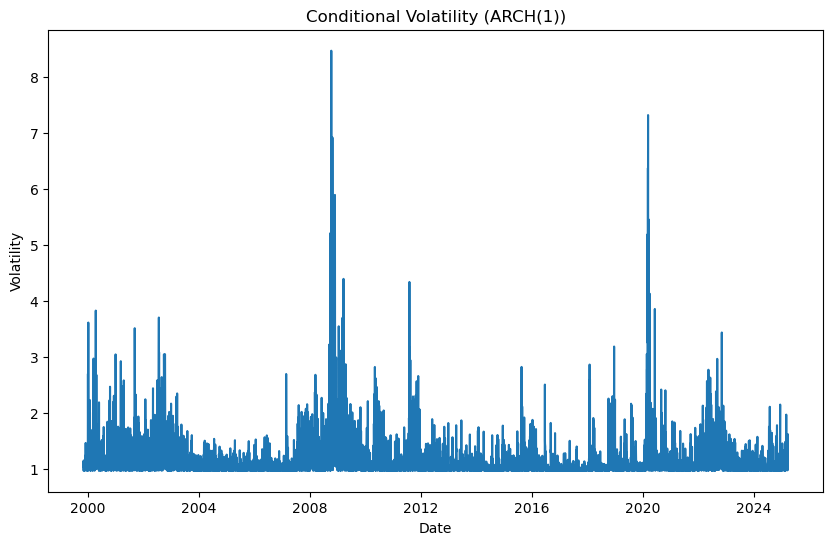

In [27]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility_arch)
plt.title('Conditional Volatility (ARCH(1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

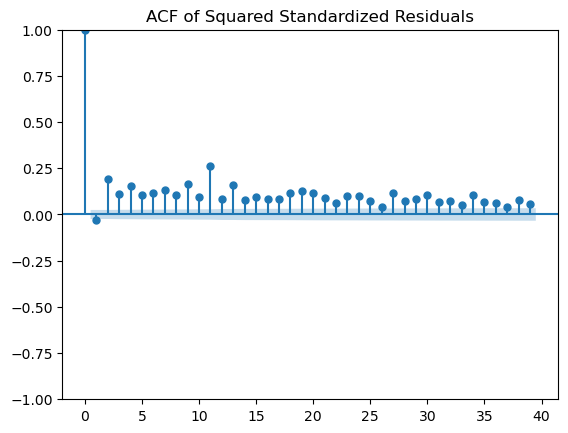

In [28]:
std_resid_arch = model_fit_arch.std_resid

plot_acf(std_resid_arch**2)
plt.title("ACF of Squared Standardized Residuals")
plt.show()

In [29]:
arch_test = het_arch(std_resid_arch)
print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 657.2945115806397
p-value: 9.168979691083245e-135


In [30]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility_arch - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility_arch - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1.16577239603172
Root Mean Squared Error (RMSE): 1.232298699376671


In [31]:
#GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model. 
#A GARCH model is an extension of the ARCH model and is typically more flexible. 
#It includes both past squared residuals (like ARCH) and past conditional variances (volatility) in the model.
#σt^2​=ω+α1​ϵt−1^2​+β1​σt−1^2​

In [32]:
# Fit the GARCH(1, 1) model
model = arch_model(returns, vol="Garch", p=1, q=1, rescale = True)
results = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 13724881412.45197
Iteration:      2,   Func. Count:     15,   Neg. LLF: 3445145046.721247
Iteration:      3,   Func. Count:     22,   Neg. LLF: 13006.317656859346
Iteration:      4,   Func. Count:     29,   Neg. LLF: 1250551911.364773
Iteration:      5,   Func. Count:     36,   Neg. LLF: 8905.212582376298
Iteration:      6,   Func. Count:     42,   Neg. LLF: 8811.106959568424
Iteration:      7,   Func. Count:     48,   Neg. LLF: 8926.674080417495
Iteration:      8,   Func. Count:     54,   Neg. LLF: 8826.45570357462
Iteration:      9,   Func. Count:     60,   Neg. LLF: 8804.61826874083
Iteration:     10,   Func. Count:     66,   Neg. LLF: 8804.008617699565
Iteration:     11,   Func. Count:     71,   Neg. LLF: 8804.008322817936
Iteration:     12,   Func. Count:     76,   Neg. LLF: 8804.008310955898
Iteration:     13,   Func. Count:     80,   Neg. LLF: 8804.00831095148
Optimization terminated successfully    (Exit mode 0)
            

In [33]:
#we are fitting a GARCH(1, 1) model, which includes one lag of both the returns and the conditional variance

In [34]:
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8804.01
Distribution:                  Normal   AIC:                           17616.0
Method:            Maximum Likelihood   BIC:                           17643.1
                                        No. Observations:                 6391
Date:                Fri, Mar 20 2026   Df Residuals:                     6390
Time:                        10:28:33   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0689  9.794e-03     -7.040  1.920e-

In [35]:
#Once we have fitted the GARCH model, we can estimate and forecast the volatility. 
#The estimated volatility represents the conditional variance of the log returns, while the forecasted volatility provides future volatility predictions.

In [36]:
# Estimate the volatility
volatility = results.conditional_volatility

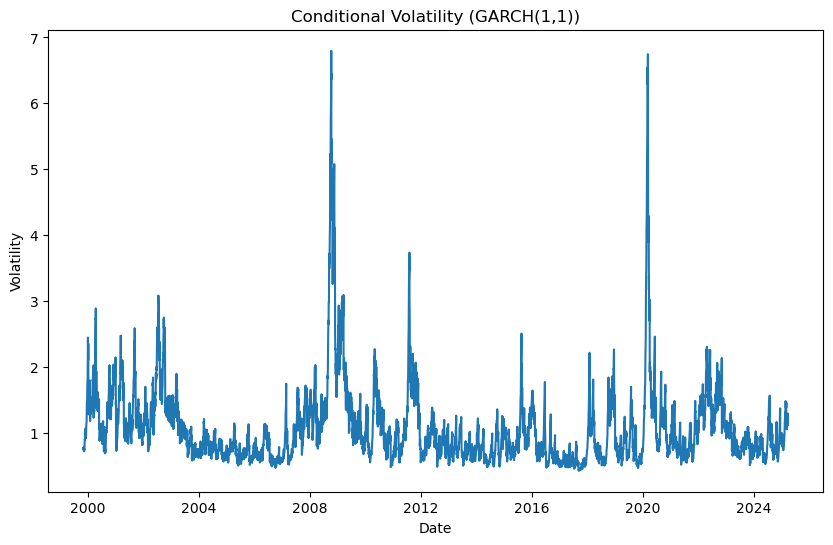

In [37]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility)
plt.title('Conditional Volatility (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

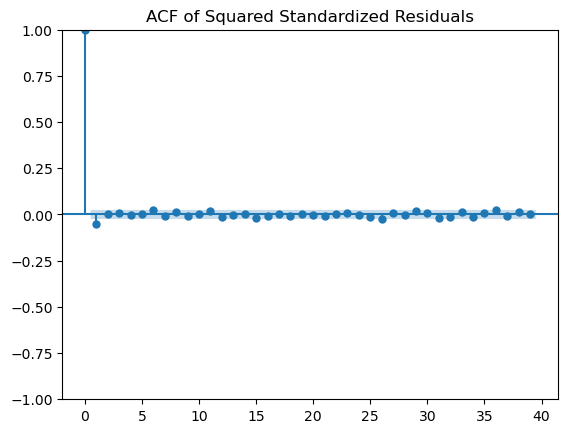

In [38]:
std_resid_garch = results.std_resid

plot_acf(std_resid_garch**2)
plt.title("ACF of Squared Standardized Residuals")
plt.show()

In [39]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1.0672239978400475
Root Mean Squared Error (RMSE): 1.230454525659641


In [40]:
#The MAE and RMSE provide measures of the average and overall forecast errors, respectively. 
#Lower values indicate better model performance.

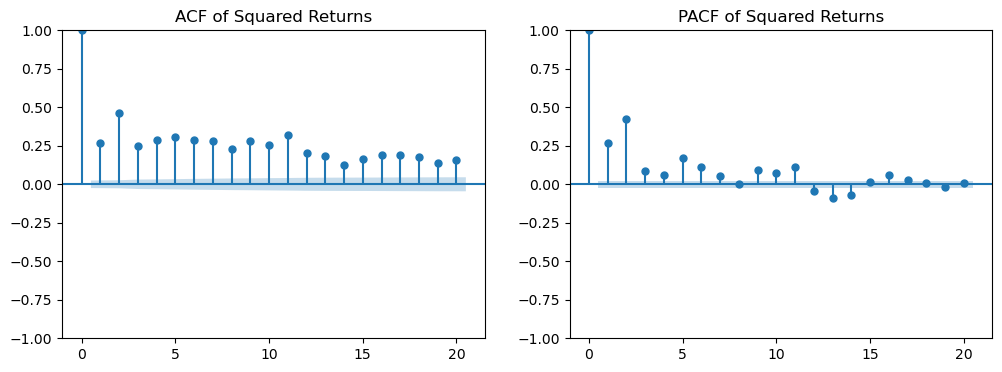

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF of squared returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(returns**2, lags=20, ax=axes[0])
axes[0].set_title("ACF of Squared Returns")

plot_pacf(returns**2, lags=20, ax=axes[1])
axes[1].set_title("PACF of Squared Returns")

plt.show()

In [42]:
#From your ACF and PACF plots of squared returns, we can determine the GARCH(p, q) parameters as follows:

#q (MA component in volatility - from ACF)
#The ACF plot shows significant spikes at lags 1, 2, and possibly 3 before tapering off.
#This suggests that q = 2 or 3 might be a good choice.

#p (AR component in volatility - from PACF)
#The PACF plot shows significant spikes at lags 1 and 2, after which it dies down.
#This suggests that p = 2 might be appropriate.
#Suggested Model: GARCH(2,2) or GARCH(2,3)
#You can first try GARCH(2,2) and compare AIC/BIC with GARCH(2,3) to decide the best model.

In [43]:
# Fit the GARCH(2, 2) model
model1 = arch_model(returns, vol="Garch", p=2, q=2, rescale = True)
results1 = model1.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 63898.65951176564
Iteration:      2,   Func. Count:     21,   Neg. LLF: 24615.153064021182
Iteration:      3,   Func. Count:     32,   Neg. LLF: 11850.541178843607
Iteration:      4,   Func. Count:     41,   Neg. LLF: 8791.175293499193
Iteration:      5,   Func. Count:     49,   Neg. LLF: 8837.544384893796
Iteration:      6,   Func. Count:     57,   Neg. LLF: 8786.106676670463
Iteration:      7,   Func. Count:     65,   Neg. LLF: 8851.013027955985
Iteration:      8,   Func. Count:     74,   Neg. LLF: 8777.501700020712
Iteration:      9,   Func. Count:     81,   Neg. LLF: 8777.384211897195
Iteration:     10,   Func. Count:     88,   Neg. LLF: 8777.254152277
Iteration:     11,   Func. Count:     95,   Neg. LLF: 8777.25859000909
Iteration:     12,   Func. Count:    103,   Neg. LLF: 8777.249007742033
Iteration:     13,   Func. Count:    110,   Neg. LLF: 8777.248550929808
Iteration:     14,   Func. Count:    117,   Neg. LLF: 8777.2485492

In [44]:
print(results1.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8777.25
Distribution:                  Normal   AIC:                           17566.5
Method:            Maximum Likelihood   BIC:                           17607.1
                                        No. Observations:                 6391
Date:                Fri, Mar 20 2026   Df Residuals:                     6390
Time:                        10:28:34   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0699  9.759e-03     -7.160  8.046e-

In [45]:
volatility1 = results1.conditional_volatility

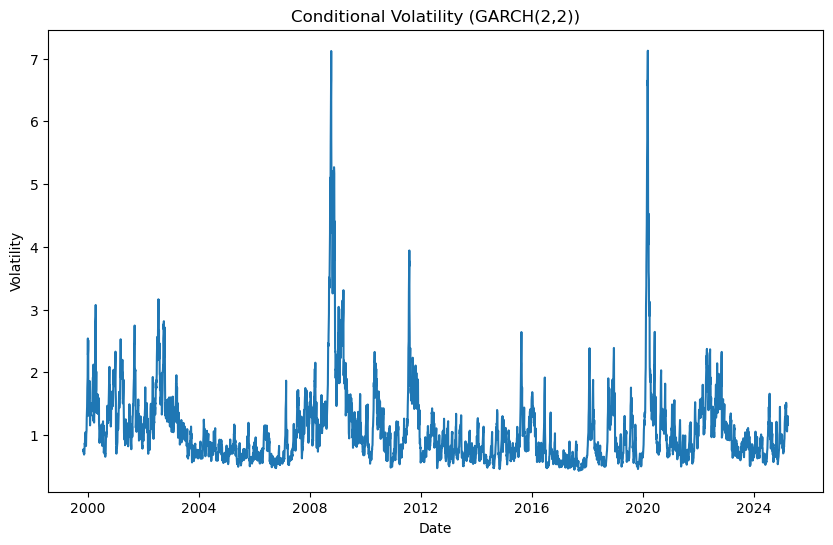

In [46]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility1)
plt.title('Conditional Volatility (GARCH(2,2))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

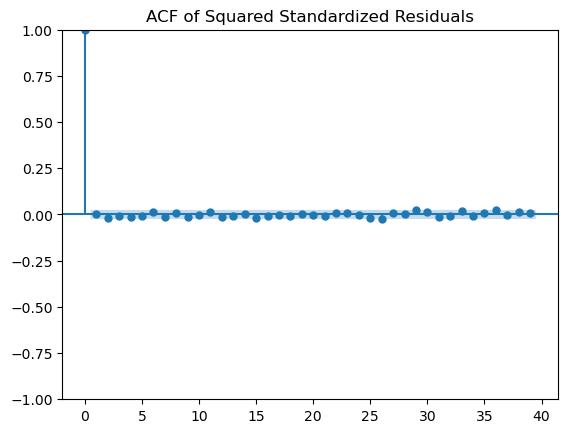

In [47]:
std_resid_garch1 = results1.std_resid

plot_acf(std_resid_garch1**2)
plt.title("ACF of Squared Standardized Residuals")
plt.show()

In [48]:
# Calculate the mean absolute error (MAE)
mae1 = np.mean(np.abs(volatility1 - returns))
print("Mean Absolute Error (MAE):", mae1)

# Calculate the root mean squared error (RMSE)
rmse1 = np.sqrt(np.mean((volatility1 - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse1)

Mean Absolute Error (MAE): 1.0652042561351065
Root Mean Squared Error (RMSE): 1.2324413935282057


In [49]:
# Fit the GARCH(2, 3) model
model2 = arch_model(returns, vol="Garch", p=2, q=3, rescale = True)
results2 = model2.fit()

Iteration:      1,   Func. Count:      9,   Neg. LLF: 144133.8884020552
Iteration:      2,   Func. Count:     23,   Neg. LLF: 4611058.315276958
Iteration:      3,   Func. Count:     33,   Neg. LLF: 10284.618986932564
Iteration:      4,   Func. Count:     43,   Neg. LLF: 19155.931592390905
Iteration:      5,   Func. Count:     52,   Neg. LLF: 13058.27176909814
Iteration:      6,   Func. Count:     62,   Neg. LLF: 5252924.07705966
Iteration:      7,   Func. Count:     72,   Neg. LLF: 8788.540576038375
Iteration:      8,   Func. Count:     80,   Neg. LLF: 8789.807396857112
Iteration:      9,   Func. Count:     89,   Neg. LLF: 8921.16715364169
Iteration:     10,   Func. Count:     98,   Neg. LLF: 8827.329113157646
Iteration:     11,   Func. Count:    108,   Neg. LLF: 8777.968584251728
Iteration:     12,   Func. Count:    116,   Neg. LLF: 8777.259610722635
Iteration:     13,   Func. Count:    124,   Neg. LLF: 8777.268878022369
Iteration:     14,   Func. Count:    133,   Neg. LLF: 8777.24877

In [50]:
print(results2.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8777.25
Distribution:                  Normal   AIC:                           17568.5
Method:            Maximum Likelihood   BIC:                           17615.8
                                        No. Observations:                 6391
Date:                Fri, Mar 20 2026   Df Residuals:                     6390
Time:                        10:28:35   Df Model:                            1
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0699  9.777e-03     -7.148  8.834e-

In [51]:
volatility2 = results2.conditional_volatility

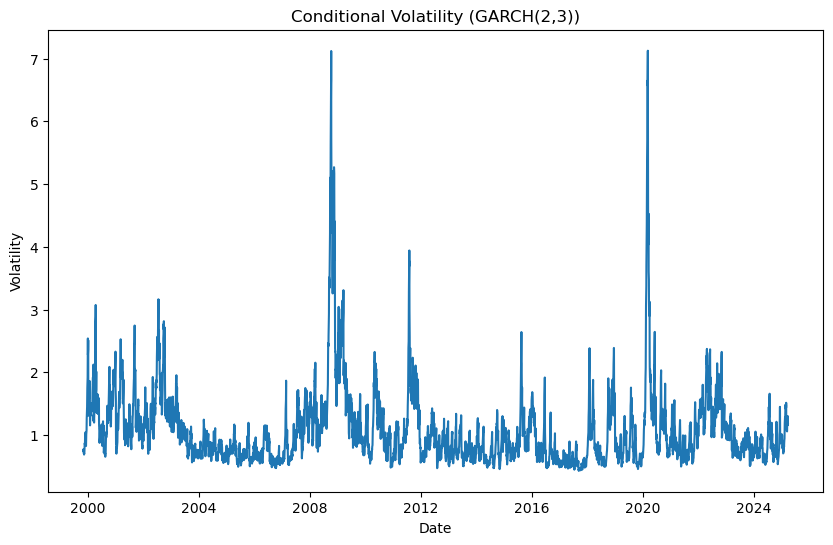

In [52]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility2)
plt.title('Conditional Volatility (GARCH(2,3))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

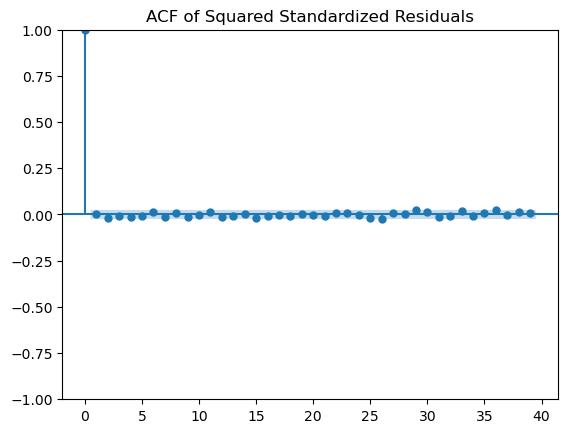

In [53]:
std_resid_garch2 = results2.std_resid

plot_acf(std_resid_garch2**2)
plt.title("ACF of Squared Standardized Residuals")
plt.show()

In [54]:
# Calculate the mean absolute error (MAE)
mae2 = np.mean(np.abs(volatility2 - returns))
print("Mean Absolute Error (MAE):", mae2)

# Calculate the root mean squared error (RMSE)
rmse2 = np.sqrt(np.mean((volatility2 - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse2)

Mean Absolute Error (MAE): 1.065208083711865
Root Mean Squared Error (RMSE): 1.2324466978417605


In [55]:
#Comparing mae and rmse
#ARCH (1)
#Mean Absolute Error (MAE): 1.16577239603172
#Root Mean Squared Error (RMSE): 1.232298699376671

#GARCH(1,1)
#Mean Absolute Error (MAE): 1.0672239978400475
#Root Mean Squared Error (RMSE): 1.230454525659641

#GARCH(2,2)
#Mean Absolute Error (MAE): 1.0652042561351065
#Root Mean Squared Error (RMSE): 1.2324413935282057


#GARCH(2,3)
#Mean Absolute Error (MAE): 1.065208083711865
#Root Mean Squared Error (RMSE): 1.2324466978417605
